# Multivariate SST time-frequency representation

Ahrabian, Looney, Stanković & Mandic, *Signal Processing* 106 (2015).
Each channel is synchrosqueezed, adaptive **multivariate bandwidth**
tiles identify oscillations common to the channels, and a **joint
instantaneous frequency**

$$
\omega_x(t)=\frac{\sum_n a_n^2(t)\,\varphi_n'(t)}{\sum_n a_n^2(t)}
$$

paints one compact TFR. This notebook follows MATLAB `example_code.m`.


## 1. Imports


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from pysdkit import SST, EMD
from pysdkit.data import load_sst_float, load_sst_doppler

plt.rcParams["figure.dpi"] = 120
print("pysdkit from:", Path(__import__("pysdkit").__file__).resolve())
print(SST())

pysdkit from: C:\Users\whenx\Desktop\PySDKit\pysdkit\__init__.py
Synchrosqueezing Transform (SST)


## 2. Bivariate noisy sinusoids (paper / `example_code` test 1)


joint TFR (511, 1020) channels 2


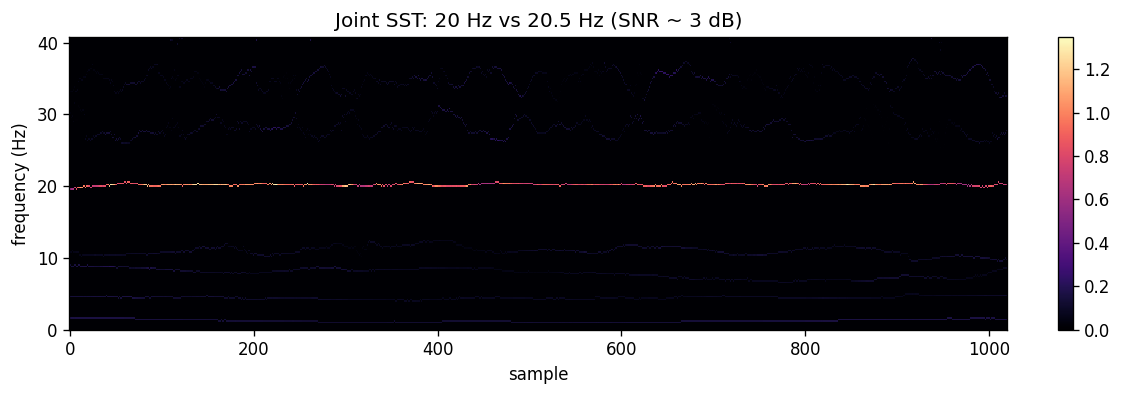

In [2]:
fs = 204.0
t = np.arange(0.0, 5.0, 1.0 / fs)
rng = np.random.default_rng(0)
x = np.vstack(
    [
        np.cos(2.0 * np.pi * 20.0 * t) + 0.5 * rng.standard_normal(t.size),
        np.cos(2.0 * np.pi * 20.5 * t) + 0.5 * rng.standard_normal(t.size),
    ]
)
sst = SST(n_voices=16, n_levels=5, wavelet="bump")
tfr, freq = sst.transform(x)
print("joint TFR", tfr.shape, "channels", x.shape[0])

fig, ax = plt.subplots(figsize=(9.5, 3.4))
im = ax.pcolormesh(
    np.arange(t.size), freq * fs, np.abs(tfr), shading="auto", cmap="magma"
)
ax.set_ylim(0, 0.2 * fs)
ax.set_xlabel("sample")
ax.set_ylabel("frequency (Hz)")
ax.set_title("Joint SST: 20 Hz vs 20.5 Hz (SNR ~ 3 dB)")
fig.colorbar(im, ax=ax, fraction=0.03)
fig.tight_layout()
plt.show()

## 3. Bivariate FM oscillation (`example_code` test 2)


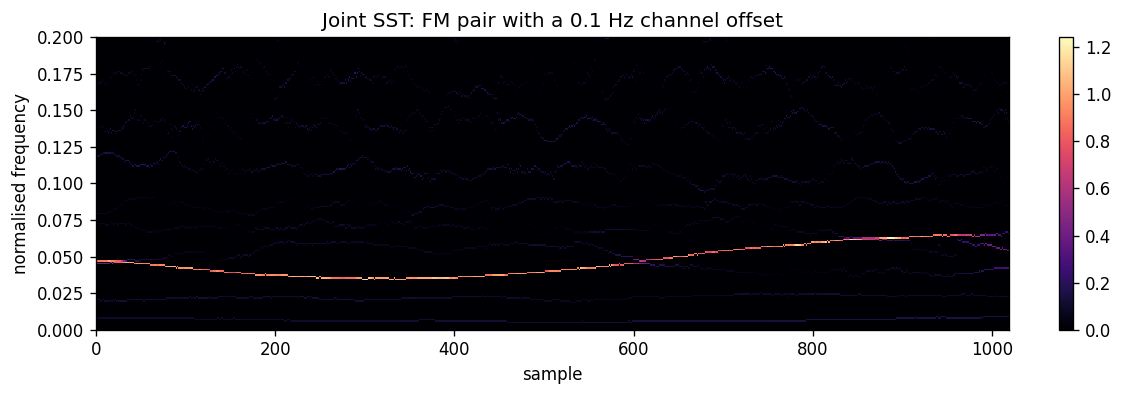

In [3]:
t = np.arange(0.0, 5.0, 1.0 / fs)
x_fm = np.vstack(
    [
        np.cos(2.0 * np.pi * ((t * 10.0) + 3.0 * np.cos(t)))
        + 0.5 * rng.standard_normal(t.size),
        np.cos(2.0 * np.pi * ((t * 10.1) + 3.0 * np.cos(t)))
        + 0.5 * rng.standard_normal(t.size),
    ]
)
tfr_fm, freq_fm = SST(n_voices=16, n_levels=5, wavelet="bump").transform(x_fm)
fig, ax = plt.subplots(figsize=(9.5, 3.4))
im = ax.pcolormesh(
    np.arange(t.size), freq_fm, np.abs(tfr_fm), shading="auto", cmap="magma"
)
ax.set_ylim(0, 0.2)
ax.set_xlabel("sample")
ax.set_ylabel("normalised frequency")
ax.set_title("Joint SST: FM pair with a 0.1 Hz channel offset")
fig.colorbar(im, ax=ax, fraction=0.03)
fig.tight_layout()
plt.show()

## 4. Real records from the MATLAB companion

Float-drift (`float.mat`) and robotic Doppler (`doppler_car.mat`),
packaged as `load_sst_float` / `load_sst_doppler`.


float (2, 1116) doppler (2, 2127)


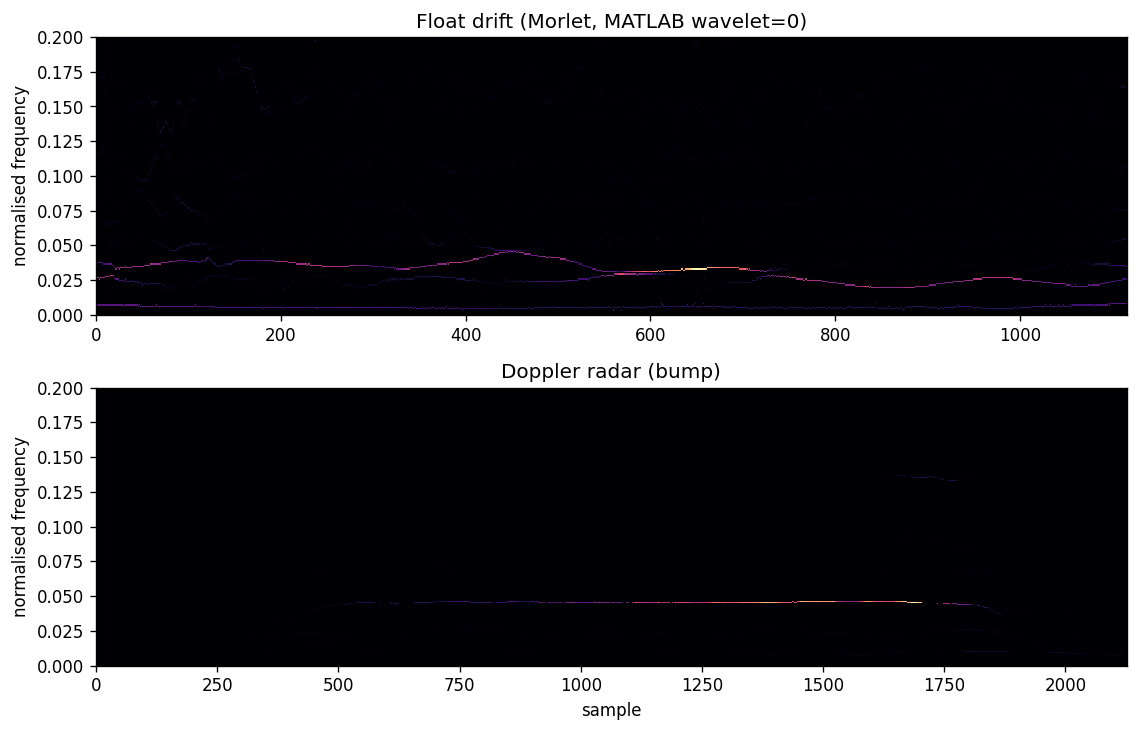

In [4]:
float_sig = load_sst_float()["signal"]
doppler_sig = load_sst_doppler()["signal"]
print("float", float_sig.shape, "doppler", doppler_sig.shape)

tfr_fl, f_fl = SST(n_voices=16, n_levels=5, wavelet="morlet").transform(float_sig)
tfr_dp, f_dp = SST(n_voices=16, n_levels=5, wavelet="bump").transform(doppler_sig)

fig, axes = plt.subplots(2, 1, figsize=(9.5, 6.2))
axes[0].pcolormesh(
    np.arange(float_sig.shape[1]), f_fl, np.abs(tfr_fl), shading="auto", cmap="magma"
)
axes[0].set_ylim(0, 0.2)
axes[0].set_title("Float drift (Morlet, MATLAB wavelet=0)")
axes[0].set_ylabel("normalised frequency")
axes[1].pcolormesh(
    np.arange(doppler_sig.shape[1]), f_dp, np.abs(tfr_dp), shading="auto", cmap="magma"
)
axes[1].set_ylim(0, 0.2)
axes[1].set_title("Doppler radar (bump)")
axes[1].set_xlabel("sample")
axes[1].set_ylabel("normalised frequency")
fig.tight_layout()
plt.show()